## Solving an XOR Classification problem 

In [21]:
import torch 
import numpy as np
import torch.nn as nn


In [22]:
torch.manual_seed(1)

np.random.seed(1)

x = np.random.uniform(low=-1 , high=1 , size=(200,2))
y = np.ones(len(x))

In [23]:
y[x[:,0] *x[:,1]<0] =0



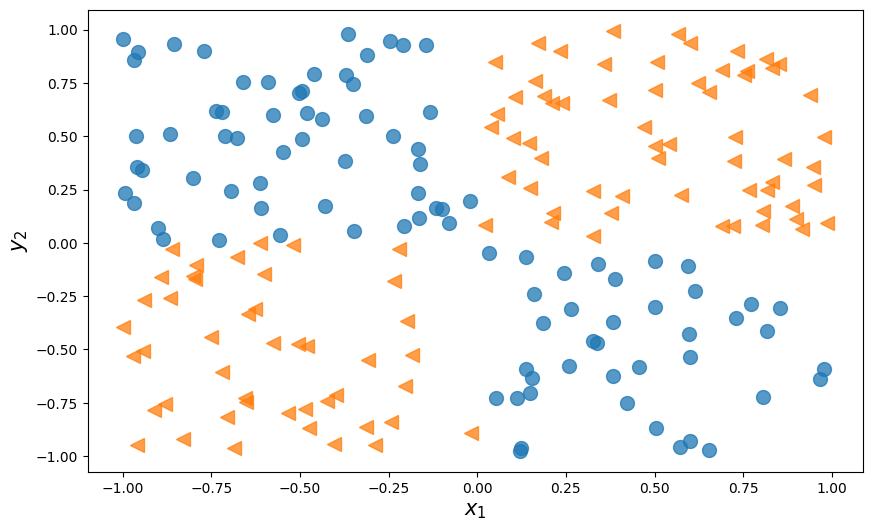

In [24]:
n_train = 100

x_train = torch.tensor(x[:n_train,:],dtype=torch.float32)
y_train = torch.tensor(y[:n_train] , dtype = torch.float32)
x_valid = torch.tensor(x[n_train:,:], dtype=torch.float32)
y_valid = torch.tensor(y[n_train:], dtype=torch.float32)


import matplotlib.pyplot as plt 
fig = plt.figure(figsize=(10,6))
plt.plot(x[y==0,0] , x[y==0,1] , 'o' , alpha = 0.75 , markersize=10)
plt.plot(x[y==1,0] , x[y==1 , 1], '<' , alpha= 0.75 , markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$y_2$', size=15)
plt.show()

In [25]:
model = nn.Sequential(
    nn.Linear(2,1),
    nn.Sigmoid()
)
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

In [26]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters() , lr=0.001)


In [27]:
# creating the Dataset 
from torch.utils.data import TensorDataset , DataLoader

train_ds = TensorDataset(x_train , y_train)
BATCH_SIZE = 2
torch.manual_seed(1)
train_dl = DataLoader(train_ds , BATCH_SIZE , shuffle=True)


In [29]:
epochs = 200

def train(model, epochs, train_dl, x_valid, y_valid):
    """TRAINING LOOP FUNCTION"""
    
    loss_hist_train = [0.0] * epochs
    accuracy_hist_train = [0.0] * epochs
    
    loss_hist_valid = [0.0] * epochs
    accuracy_hist_valid = [0.0] * epochs
    
    n_train = len(train_dl.dataset)
    
    for e in range(epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            pred = model(x_batch)[:, 0]
            loss = loss_fn(pred, y_batch)
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            
            # Accumulate training metrics
            loss_hist_train[e] += loss.item() * x_batch.size(0)
            
            # FIXED: Removed parentheses and updated list element instead of overwriting the list
            is_correct = ((pred >= 0.5).float() == y_batch).float()
            accuracy_hist_train[e] += is_correct.sum().item()
            
        # Average over the entire training set size
        loss_hist_train[e] /= n_train
        accuracy_hist_train[e] /= n_train
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            pred_valid = model(x_valid)[:, 0]
            loss_valid = loss_fn(pred_valid, y_valid)
            loss_hist_valid[e] = loss_valid.item()
            
            is_correct_valid = ((pred_valid >= 0.5).float() == y_valid).float()
            accuracy_hist_valid[e] = is_correct_valid.mean().item()
    
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

# Run training
history = train(model, 
                epochs, 
                train_dl, 
                x_valid, 
                y_valid)

Text(0.5, 0, 'Epochs')

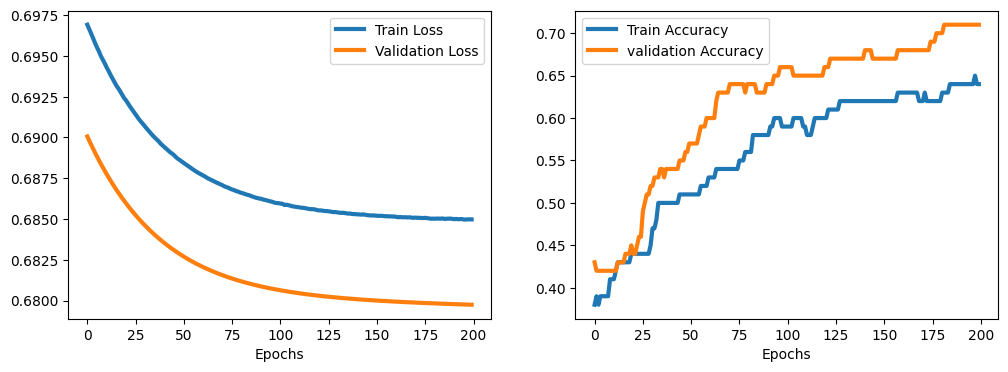

In [36]:
fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
plt.plot(history[0], lw=3)
plt.plot(history[1] , lw=3)
plt.legend(['Train Loss', 'Validation Loss'])
ax.set_xlabel('Epochs')
ax= fig.add_subplot(1,2,2)
plt.plot(history[2], lw=3)
plt.plot(history[3], lw=3)
plt.legend(['Train Accuracy','validation Accuracy'] , fontsize=10)
ax.set_xlabel('Epochs')

C:\Users\Sushant\AppData\Local\Temp\ipykernel_24340\4230592614.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
C:\Users\Sushant\AppData\Local\Temp\ipykernel_24340\4230592614.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, 0.02))


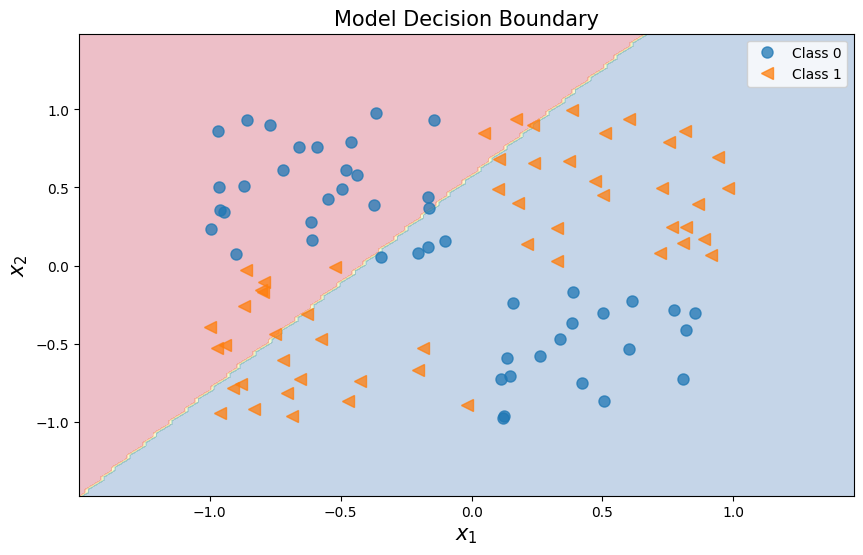

In [37]:
def plot_decision_boundary(model, x_data, y_data):
    # Set model to evaluation mode
    model.eval()
    
    # 1. Define the grid range with a little padding
    x_min, x_max = x_data[:, 0].min() - 0.5, x_data[:, 0].max() + 0.5
    y_min, y_max = x_data[:, 1].min() - 0.5, x_data[:, 1].max() + 0.5
    
    # Create meshgrid with fine resolution (e.g., 100x100 points)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Flatten the grid and convert to a PyTorch tensor
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    # 2. Get model predictions for every point on the grid
    with torch.no_grad():
        preds = model(grid_tensor)[:, 0] # Adjust index if needed
        # Apply threshold (0.5) to get binary classes 0 or 1, matching your training logic
        preds = (preds >= 0.5).float()
        
    # Reshape predictions back to the meshgrid shape
    Z = preds.numpy().reshape(xx.shape)
    
    # 3. Plot the decision boundary and original data points
    plt.figure(figsize=(10, 6))
    
    # Contour plot for regions
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Spectral)
    
    # Scatter plot for actual data points (using your class labels y_data)
    # Convert y_data to numpy if it's a tensor
    y_np = y_data.numpy() if isinstance(y_data, torch.Tensor) else y_data
    x_np = x_data.numpy() if isinstance(x_data, torch.Tensor) else x_data
    
    plt.plot(x_np[y_np == 0, 0], x_np[y_np == 0, 1], 'o', alpha=0.75, markersize=8, label='Class 0')
    plt.plot(x_np[y_np == 1, 0], x_np[y_np == 1, 1], '<', alpha=0.75, markersize=8, label='Class 1')
    
    plt.xlabel(r'$x_1$', size=15)
    plt.ylabel(r'$x_2$', size=15)
    plt.title('Model Decision Boundary', size=15)
    plt.legend()
    plt.show()

# Call the function using your training or validation data
plot_decision_boundary(model, x_train, y_train)

In [38]:
model_2 = nn.Sequential(
    nn.Linear(2,4),
    nn.ReLU(),
    nn.Linear(4,4),
    nn.ReLU(),
    nn.Linear(4,1),
    nn.Sigmoid()
)
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model_2.parameters() , lr=0.015)
model_2

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

Text(0.5, 0, 'Epochs')

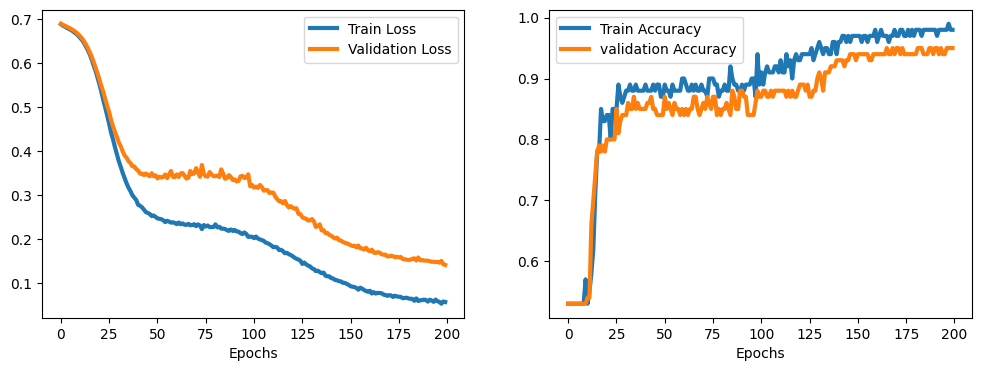

In [39]:
history = train(model_2,
                  epochs,
                  train_dl,
                  x_valid,
                  y_valid)

fig = plt.figure(figsize=(12,4))
ax = fig.add_subplot(1,2,1)
plt.plot(history[0], lw=3)
plt.plot(history[1] , lw=3)
plt.legend(['Train Loss', 'Validation Loss'])
ax.set_xlabel('Epochs')
ax= fig.add_subplot(1,2,2)
plt.plot(history[2], lw=3)
plt.plot(history[3], lw=3)
plt.legend(['Train Accuracy','validation Accuracy'] , fontsize=10)
ax.set_xlabel('Epochs')

C:\Users\Sushant\AppData\Local\Temp\ipykernel_24340\4230592614.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
C:\Users\Sushant\AppData\Local\Temp\ipykernel_24340\4230592614.py:11: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, 0.02))


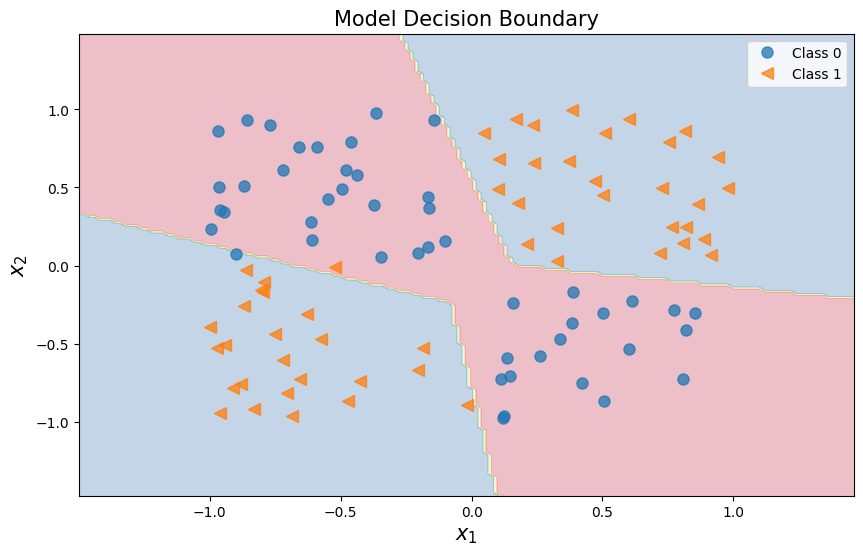

In [40]:
plot_decision_boundary(model_2, x_train, y_train)